# check the content produced by the summaries

In [1]:
import numpy as np
import os
from matplotlib import pyplot as plt
from src.evaluation import plotting, example_events


CUDA not avaliable, using CPU


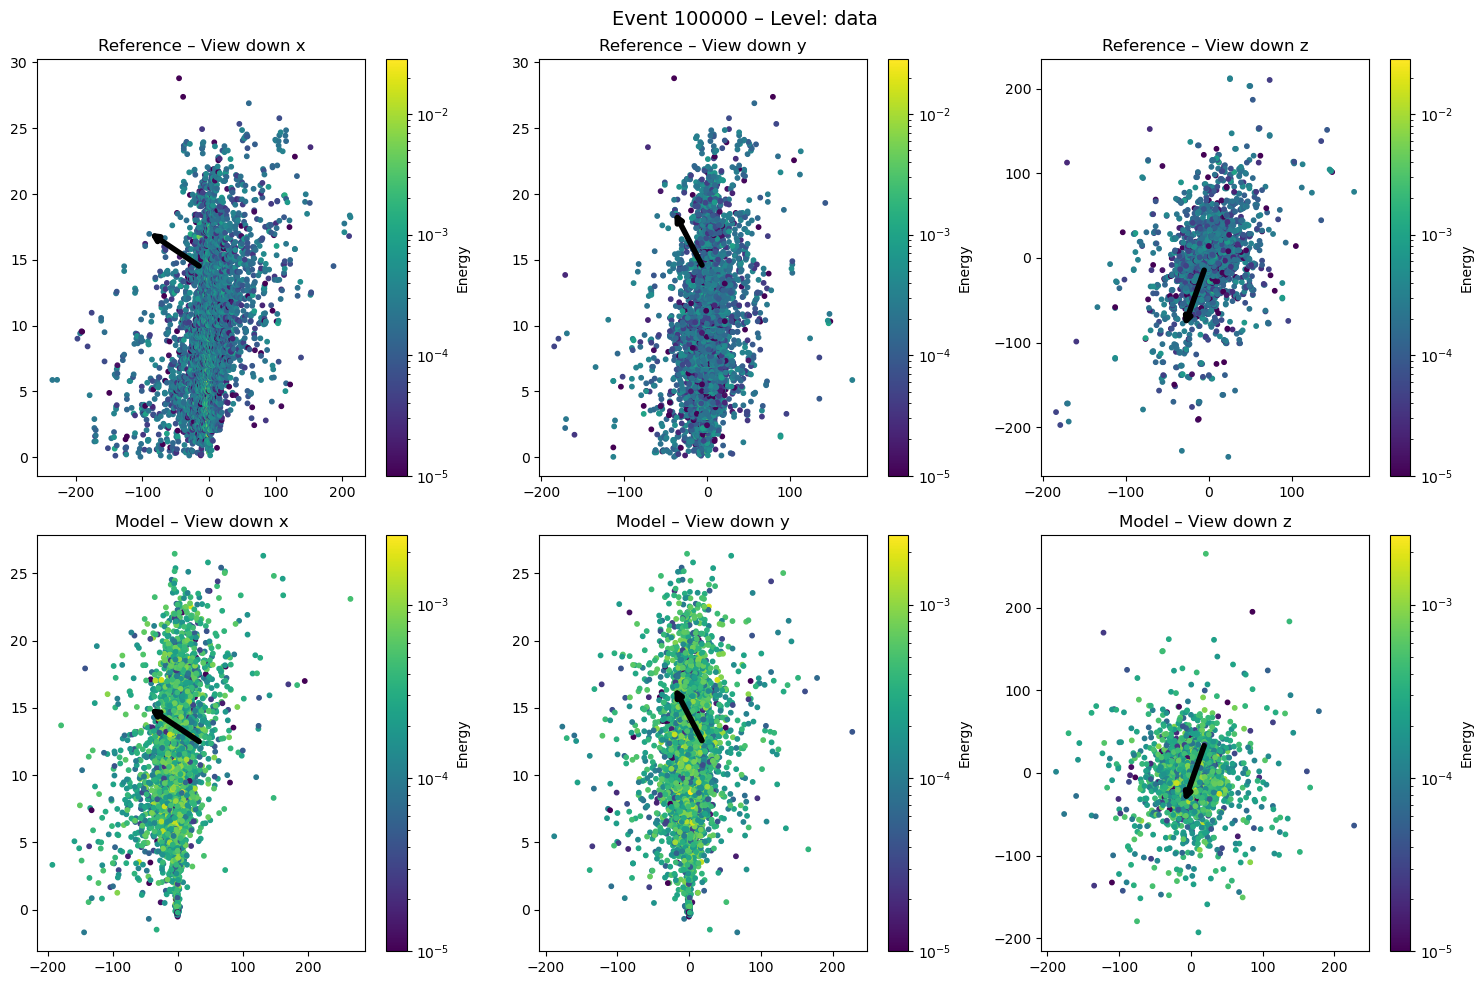

In [2]:
model_path = "/data/dust/user/dayhallh/data/CaloClouds_diffusion/logs/2026_08_06__17_14_44/checkpoints/2026-08-07_16-45-03_model.pt"
event_index = 100000
example_events.plot_example_events(
    model_path=model_path,
    event_index=event_index,
    level="data",
    data_part="test",
    output_path=None,
)


CUDA not avaliable, using CPU


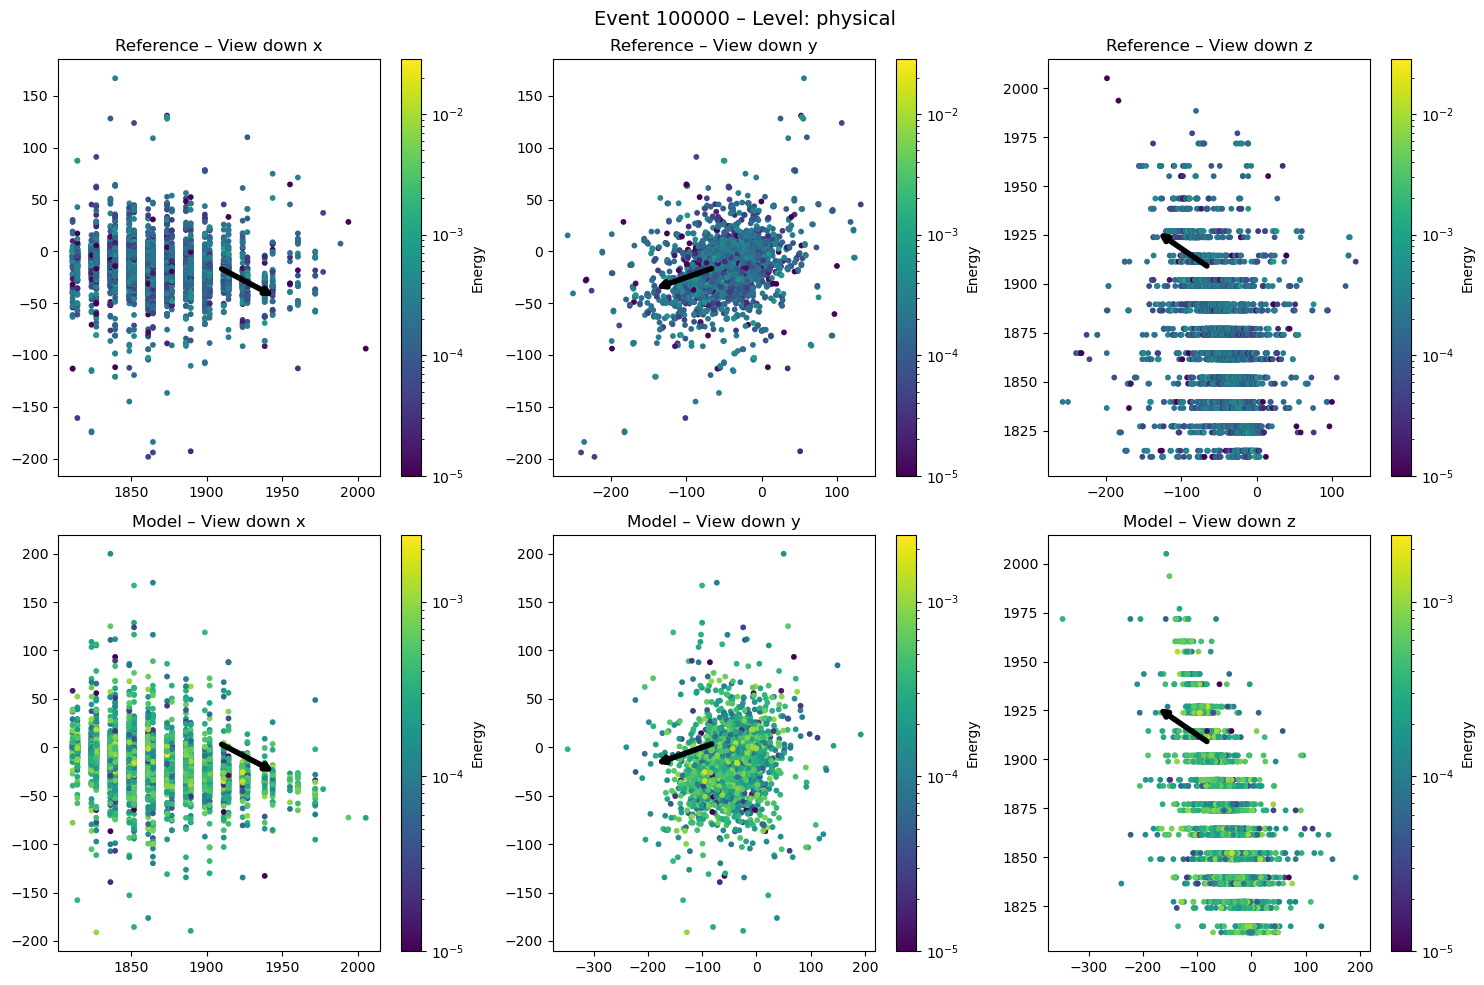

In [3]:

example_events.plot_example_events(
    model_path=model_path,
    event_index=event_index,
    level="physical",
    data_part="test",
    output_path=None,
)


CUDA not avaliable, using CPU


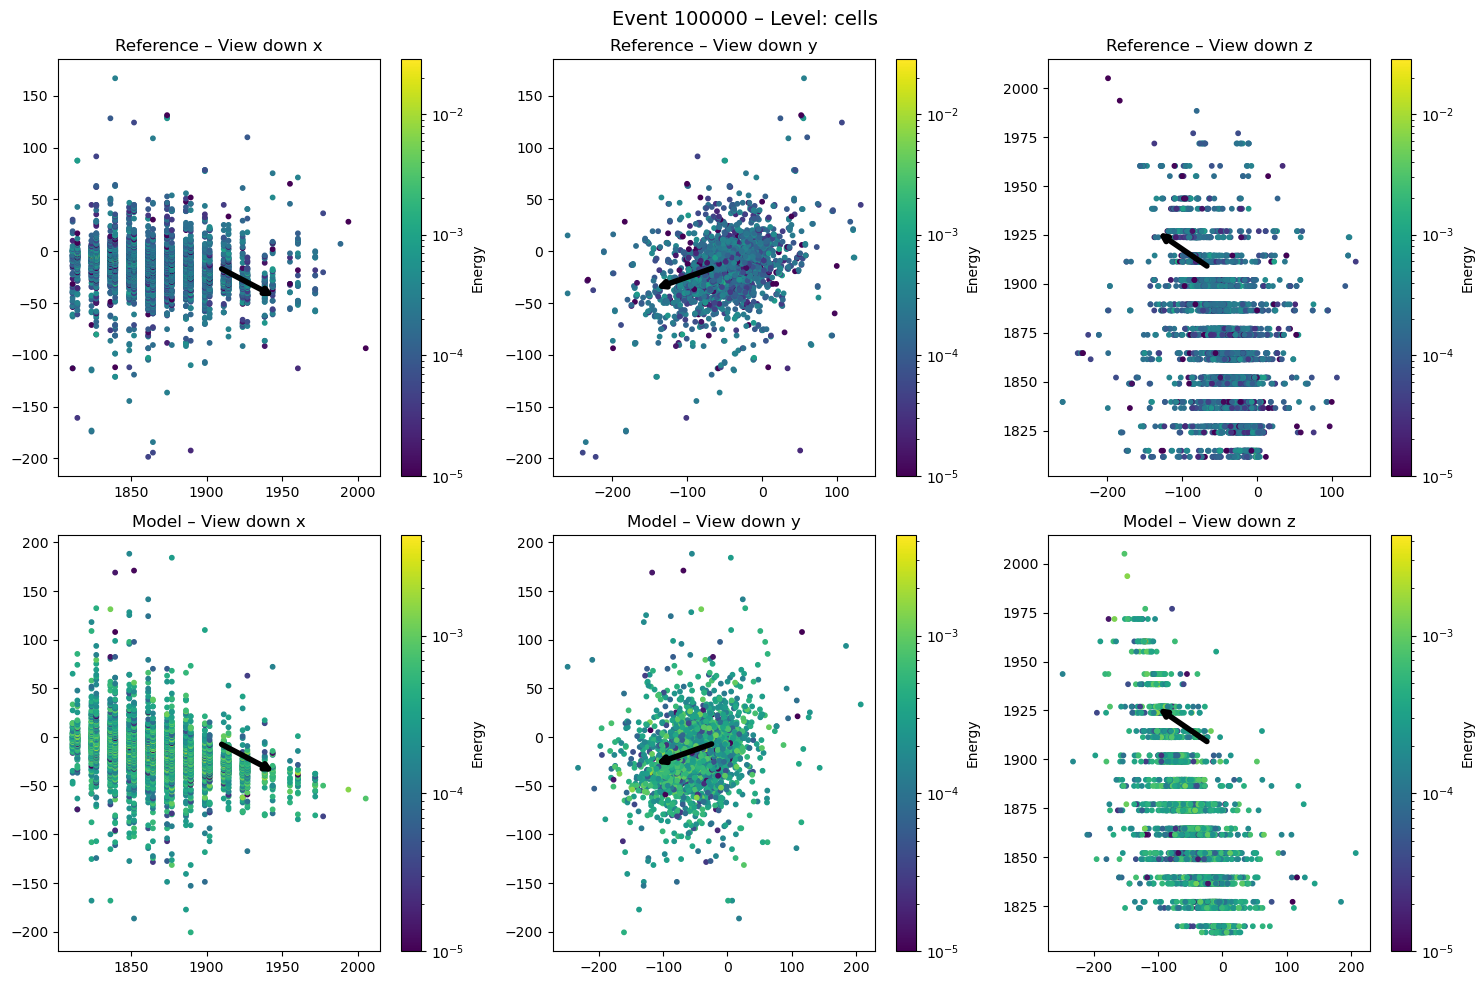

In [4]:

example_events.plot_example_events(
    model_path=model_path,
    event_index=event_index,
    level="cells",
    data_part="test",
    output_path=None,
)


In [5]:
ref_path = "/data/dust/user/dayhallh/data/CaloClouds_diffusion/precalculated_reference/sim-E1261AT600AP180-180_file_/pretest_Total1000_NoPick.npz"
sample_path = model_path.replace(".pt", "_summary.npz")

ref = np.load(ref_path)
sample_path = np.load(sample_path)
# first dimension is events
print(len(ref.keys()), {key:ref[key].shape for key in list(ref.keys())})

13 {'cond': (1000, 4), 'pca': (1000, 3), 'pca_top4': (1000, 3), 'event_energy': (1000,), 'cell_energies': (1000, 49), 'cell_energies_edges': (50,), 'radial_energy': (1000, 49), 'radial_energy_edges': (50,), 'layer_energies': (1000, 30), 'event_occupancies': (1000,), 'radial_occupancies': (1000, 49), 'radial_occupancies_edges': (50,), 'layer_occupancies': (1000, 30)}


In [6]:
plotting.RatioPlots?

Init signature:
plotting.RatioPlots(
    x_labels,
    truth_bin_heights,
    binnings,
    truth_label='g4',
    truth_color=(0.5, 0.5, 0.5, 0.5),
    max_cols=3,
    logx=False,
    logy=False,
)
Docstring:      <no docstring>
File:           ~/training/splitCC/CaloClouds_diffusion/scripts/src/evaluation/plotting.py
Type:           type
Subclasses:     

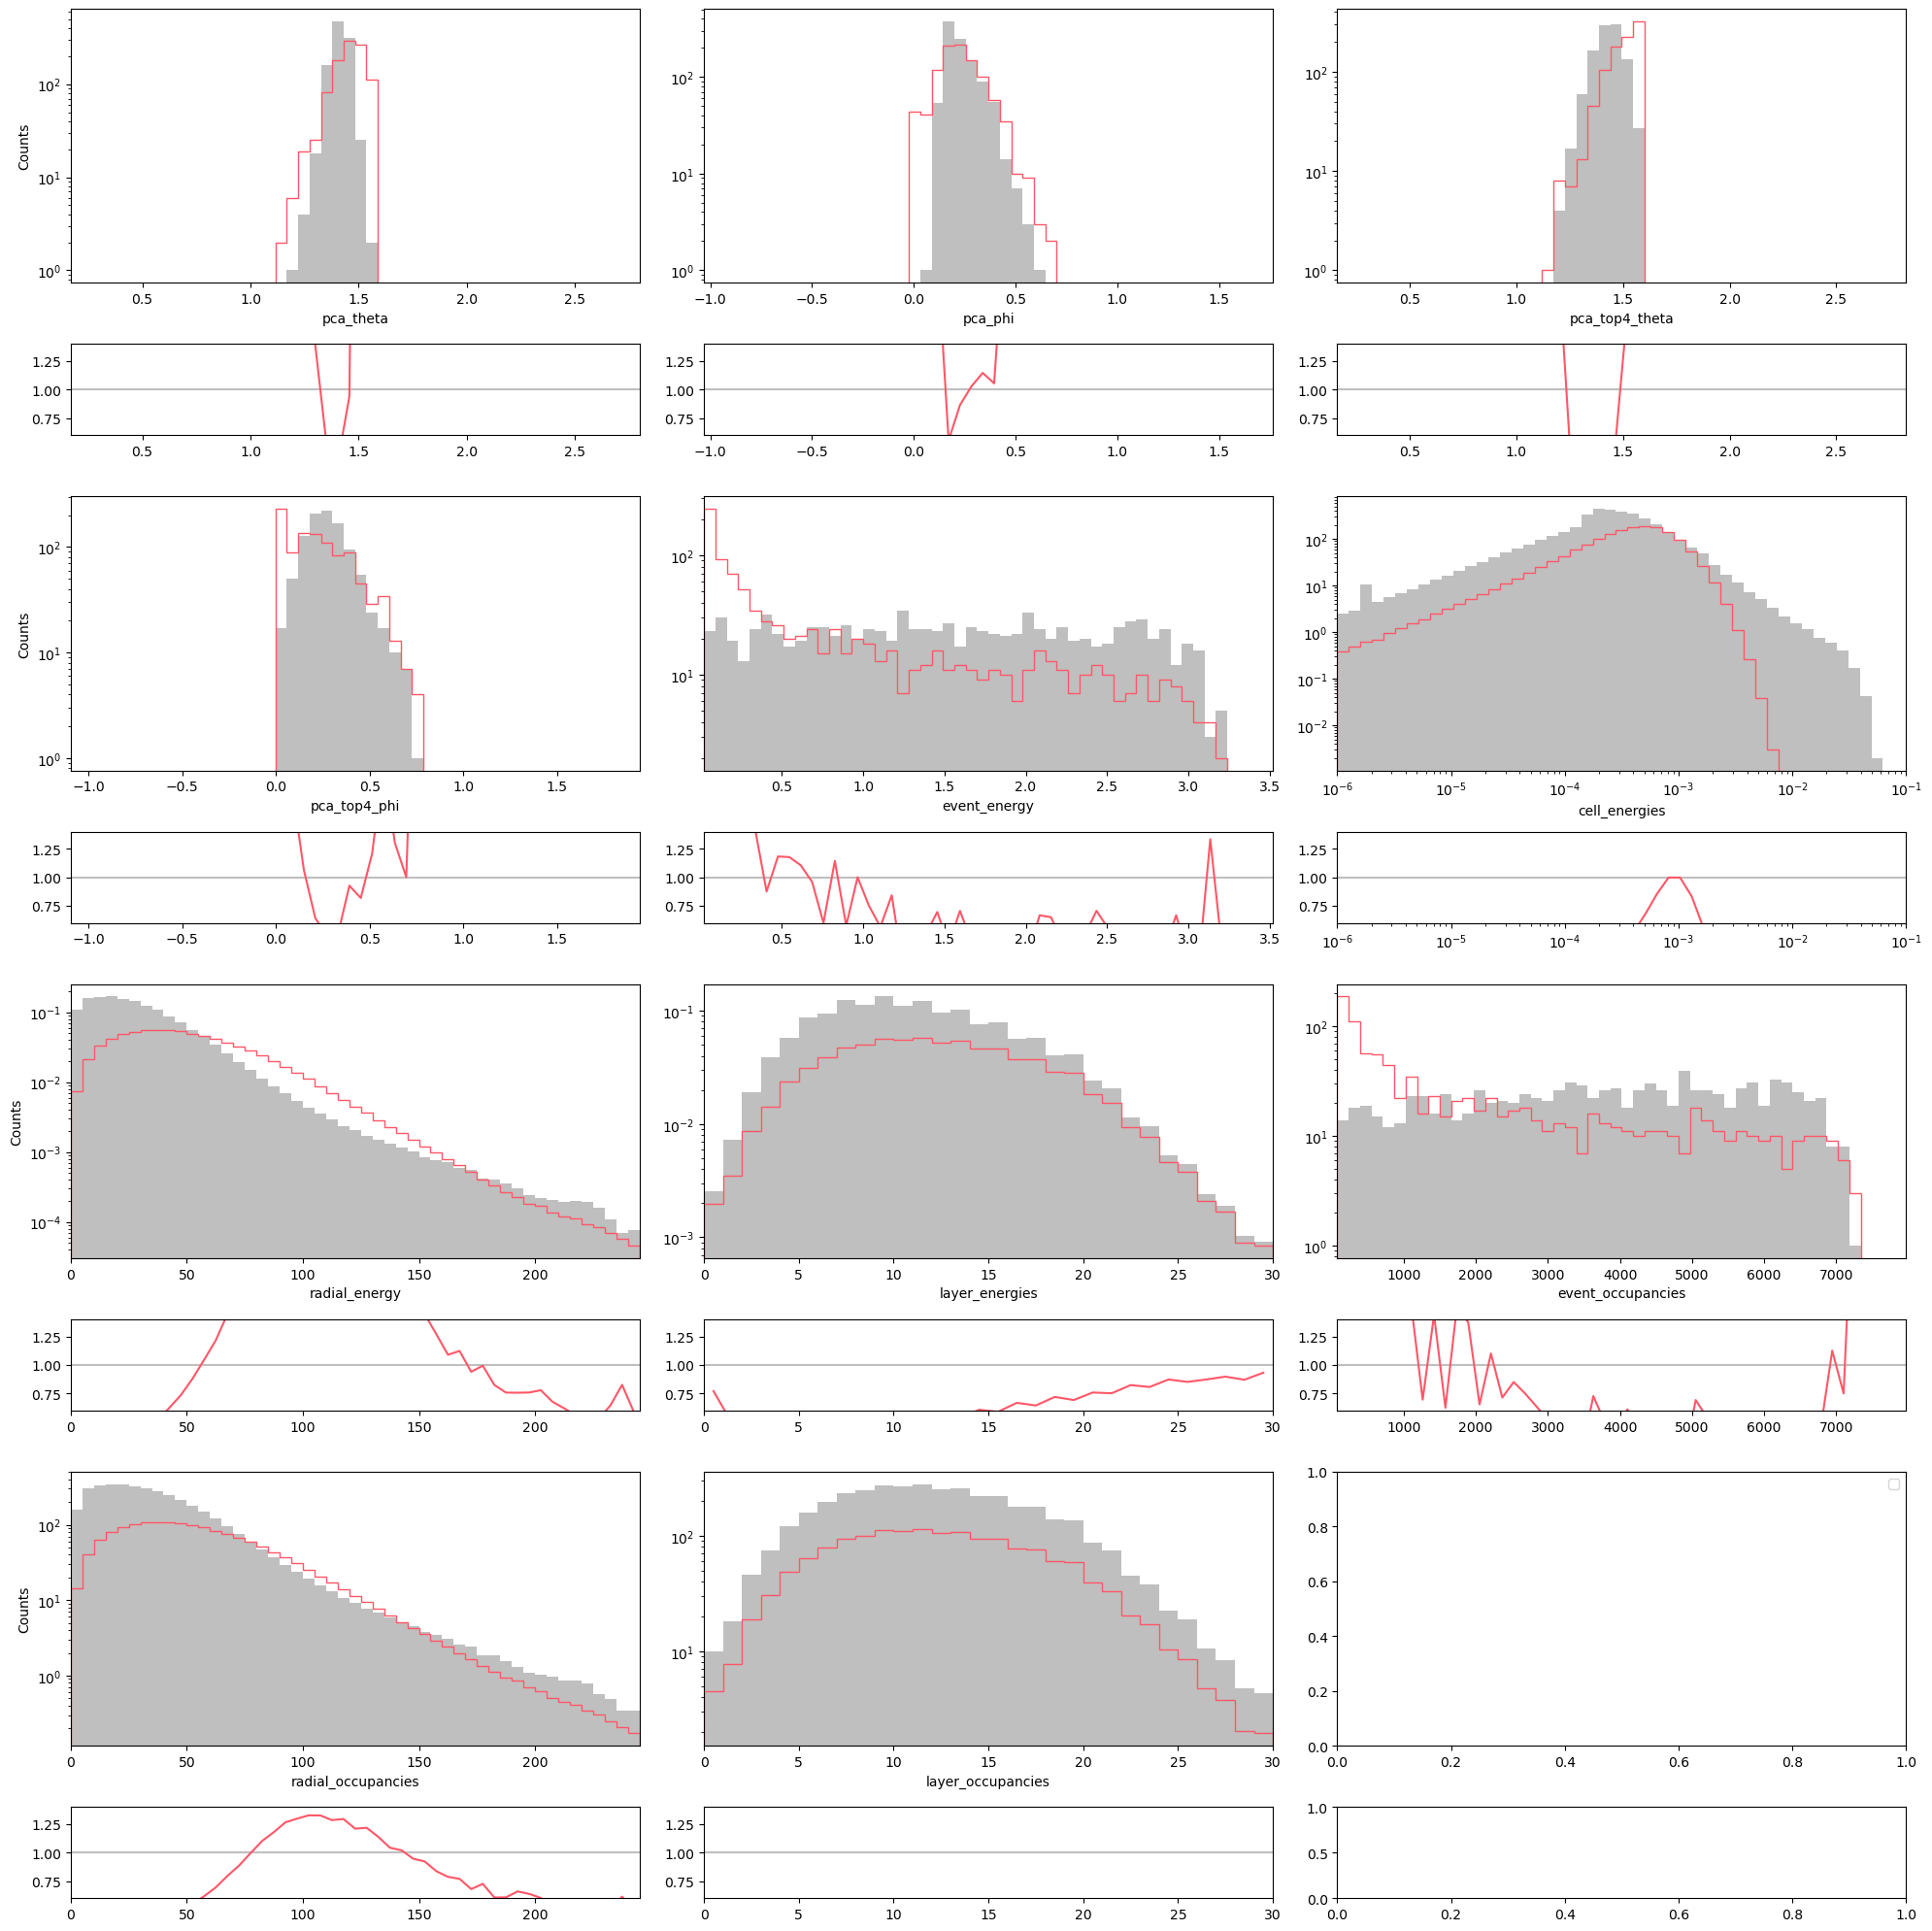

In [10]:
sample = sample_path


def pca_to_angles(pca):
    """Convert pca direction vectors into (theta, phi) angles.

    theta is measured from the z axis, phi is the angle in the x-y plane.
    """
    x = pca[:, 0]
    y = pca[:, 1]
    z = pca[:, 2]
    r = np.sqrt(x**2 + y**2 + z**2)
    theta = np.arccos(np.clip(z / r, -1.0, 1.0))
    phi = np.arctan2(y, x)
    return theta, phi


def augment_with_angles(data):
    """Return a dict copy of data with pca keys replaced by angle keys."""
    augmented = {}
    for key in data.keys():
        if "pca" in key and not key.endswith("_edges"):
            theta, phi = pca_to_angles(data[key])
            augmented[f"{key}_theta"] = theta
            augmented[f"{key}_phi"] = phi
        else:
            augmented[key] = data[key]
    return augmented


a_ref = augment_with_angles(ref)
a_sample = augment_with_angles(sample)


def bin_heights_and_edges(data, key):
    """Compute bin heights and edges for a given key."""
    values = data[key]
    edges_key = f"{key}_edges"
    if edges_key in data:
        edges = data[edges_key]
        heights = np.mean(values, axis=0)
    elif values.ndim == 1:
        ref_values = data[key]
        r_min, r_max = np.nanmin(ref_values), np.nanmax(ref_values)
        if abs(r_min - r_max) < 2:
            r_min -= 1
            r_max += 1
        r_min -= abs(r_min*0.1)
        r_max += abs(r_max*0.1)
        edges = np.linspace(r_min, r_max, 51)
        heights, _ = np.histogram(values, bins=edges)
    else:
        heights = np.mean(values, axis=0)
        edges = np.linspace(0, heights.shape[0], heights.shape[0] + 1)
    return heights, edges


# collect the keys to plot (skip cond and any *_edges keys)
plot_keys = [
    key
    for key in a_ref.keys()
    if key != "cond" and not key.endswith("_edges")
]

x_labels = plot_keys
ref_heights = []
binnings = []
for key in plot_keys:
    heights, edges = bin_heights_and_edges(a_ref, key)
    ref_heights.append(heights)
    binnings.append(edges)

logx = [x_label == "cell_energies" for x_label in x_labels]
logy = True

ratio_plots = plotting.RatioPlots(x_labels, ref_heights, binnings, logx=logx, logy=logy)

sample_heights = [bin_heights_and_edges(a_sample, key)[0] for key in plot_keys]
ratio_plots.add_comparison(sample_heights, label="model", colour=plotting.nice_hex[0][3])
ratio_plots.finalise()

In [8]:
plt.hist([ref['pca_theta'], sample['pca_theta']], histtype='step', label=('g4', 'sample'))
plt.legend()

KeyError: 'pca_theta is not a file in the archive'